<a href="https://colab.research.google.com/github/j-yxn/Air-Quality-Prediction/blob/main/Air_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Beijing PM2.5 Air Quality with an LSTM Neural Network

**Objective:** Predict the next hour's PM2.5 concentration (fine particulate matter, the pollutant most closely linked to respiratory and cardiovascular health risk) using the past 48 hours of weather and pollution data.

Air quality is a *multivariate time series*,  meaning it can't be treated like as a usual ML problem. Conventional methods such as shuffling rows and dropping missing values can't be done, and the model needs to learn temporal patterns (e.g. pollution build-up overnight, dispersal with wind).

**Approach:**
1. Clean and interpolate a real-world hourly dataset (2010–2014, 43,824 hours) while preserving temporal order
2. Engineer 3D "sliding window" sequences suitable for a recurrent network
3. Train an LSTM (Long Short-Term Memory) network to forecast one hour ahead
4. Benchmark it against a naive persistence baseline to prove the model is actually learning something useful, not just repeating the last known value
5. Evaluate performance in real, interpretable units (µg/m³), not just scaled loss

**Stack:** Python, Pandas, NumPy, Scikit-learn, TensorFlow/Keras, Matplotlib, Seaborn

**Dataset:** [Beijing PM2.5 Data Set](https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data), UCI Machine Learning Repository


In [20]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import ssl

### **I. Data Acquisition & Setup**

Incorporating the Beijing PM2.5 Data Set from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data). This data contains hourly data for **PM2.5 concentration** (amount of fine particulate matter suspended in a given volume of air), **dew point**, **temperature**, **pressure**, **wind direction**, **wind speed**, and **precipitation**.

The raw data arrives split into separate `year`, `month`, `day`, `hour` columns rather than a single timestamp. Since everything downstream (windowing, train/test splitting, plotting) depends on the data being in strict chronological order, the first step is to merge these into one `datetime` index.

In [21]:
# fetch dataset
beijing_pm2_5 = fetch_ucirepo(id=381)
# data (as pandas dataframes)
X = beijing_pm2_5.data.features
y = beijing_pm2_5.data.targets
# metadata
print(beijing_pm2_5.metadata)
# variable information
print(beijing_pm2_5.variables)

# combing into a single df
df = pd.concat([X, y], axis=1)

# create a unified datetime index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('datetime')
df = df.drop(columns=['year',  'month', 'day', 'hour'])

print("\nData after merginging and setting DateTime index")
print(df.head())

{'uci_id': 381, 'name': 'Beijing PM2.5', 'repository_url': 'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data', 'data_url': 'https://archive.ics.uci.edu/static/public/381/data.csv', 'abstract': 'This hourly data set contains the PM2.5 data of US Embassy in Beijing. Meanwhile, meteorological data from Beijing Capital International Airport are also included. ', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 43824, 'num_features': 11, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['pm2.5'], 'index_col': ['No'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C5JS49', 'creators': ['Song Chen'], 'intro_paper': {'ID': 432, 'type': 'NATIVE', 'title': "Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating", 'authors': 'Xuan Liang, T. Zou, Bi

### **II. EDA**

Before any training or modeling, we need to discover and handle missing values, and use visual tools to analyze our target variable (PM2.5) for seasonal trends.

In [22]:
# check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
pm2.5    2067
dtype: int64


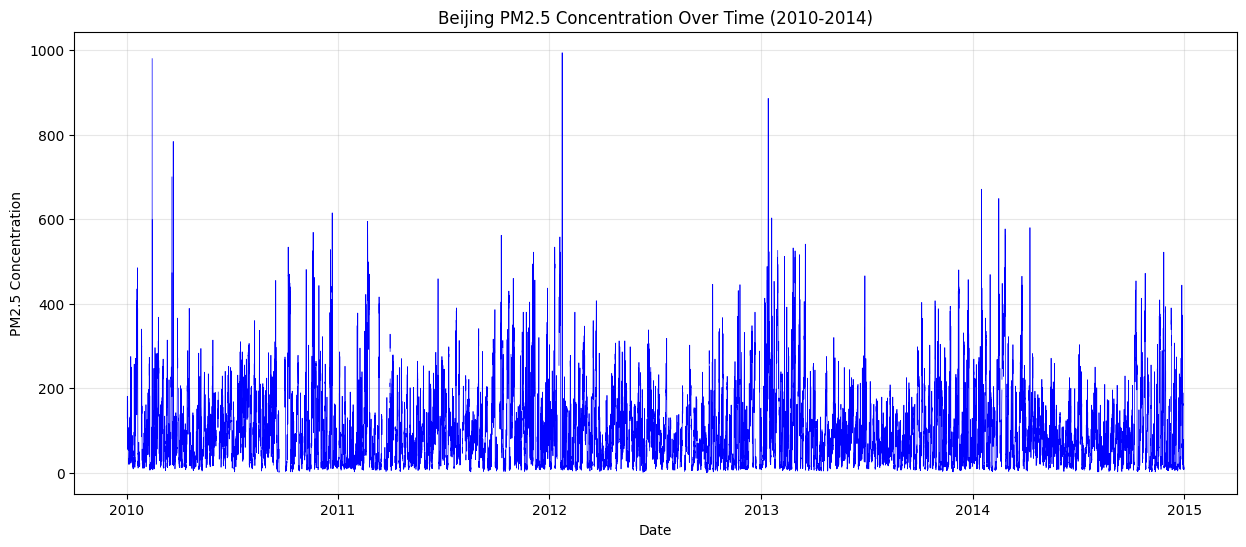

In [23]:
# plot the target variable over time
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['pm2.5'], color='blue', linewidth=0.5)
plt.title('Beijing PM2.5 Concentration Over Time (2010-2014)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.grid(True, alpha=0.3)
plt.show()


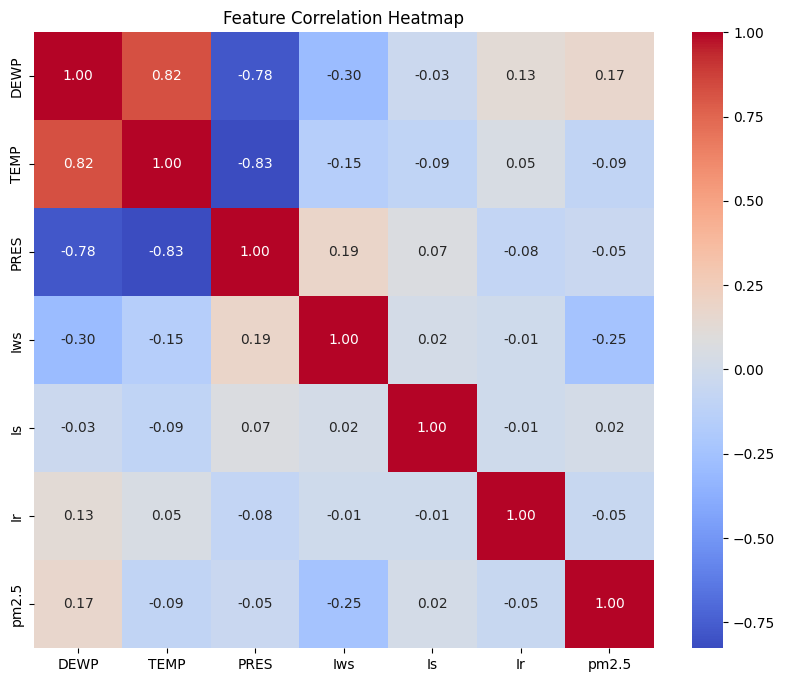

In [24]:
# correlation heatmap to see what impacts PM2.5
# will exclude categorical variable 'cbwd'
n_df = df.drop(columns=['cbwd'])
plt.figure(figsize=(10, 8))
sns.heatmap(n_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

The output results in **2067 missing values**, which means it will need to be handled. In usual ML scenarios, if there is a missing value, the row can be simply removed or fit with the overall average of the column.

However, for scenarios dependent on time series, there are two main reasons it cannot happen:
1. If a row is removed, a specific point in time is removed, meaning that there is a "jump" in time. Models need to be continuous, evenly-spaced sequences to correctly understand patterns.
2. Using means ignores seasonality, which can be an important indicator, thus resulting in artificial data that is not true (e.g. filling a 3am winter reading with the yearly average would erase the fact that pollution is typically worse at night and in winter).

Therefore, solutions that respect the natural flow of time must be used:
1. **Forward Fill** (`ffill`): takes the last known value and carries it forward.
2. **Linear Interpolation**: draws a straight line between the last known value and the next known value, and fills the gap proportionally. This is a better fit here because PM2.5 tends to change gradually hour-to-hour rather than jumping instantly, so interpolation approximates the true underlying trend more closely than simply repeating the last value.

### **III. Preprocessing**
For this scenario, **interpolation** will be used, followed by scaling all input features onto a similar scale (0–1).

In [25]:
# handle missing values
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')
df = df.bfill() # Catches any NaNs right at the start of the dataset

print("Missing values after interpolation:")
print(df.isnull().sum())

Missing values after interpolation:
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
pm2.5    0
dtype: int64


In [26]:
# convert categorical data and encode
# converts text such as 'NW', 'cv' into numbers 0, 1, 2, ...
encoder = LabelEncoder()
df['cbwd'] = encoder.fit_transform(df['cbwd'])
# scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

print("\nScaled Data:")
print(scaled_df.head())


Scaled Data:
                         DEWP      TEMP      PRES      cbwd       Iws   Is  \
datetime                                                                     
2010-01-01 00:00:00  0.279412  0.131148  0.545455  0.333333  0.002290  0.0   
2010-01-01 01:00:00  0.279412  0.114754  0.527273  0.333333  0.007639  0.0   
2010-01-01 02:00:00  0.279412  0.131148  0.509091  0.333333  0.010698  0.0   
2010-01-01 03:00:00  0.279412  0.081967  0.509091  0.333333  0.016047  0.0   
2010-01-01 04:00:00  0.294118  0.114754  0.490909  0.333333  0.021396  0.0   

                      Ir     pm2.5  
datetime                            
2010-01-01 00:00:00  0.0  0.129779  
2010-01-01 01:00:00  0.0  0.129779  
2010-01-01 02:00:00  0.0  0.129779  
2010-01-01 03:00:00  0.0  0.129779  
2010-01-01 04:00:00  0.0  0.129779  


### **IV. Creating 3D Sequences (Windowing)**

Converting the 2D dataset into 3D sequences by using a "lookback" window to define how many past hours the model should see to predict the next hour.

**Why 3D?**

A standard ML model (e.g. linear regression, random forest) takes a single row of features per prediction — shape `(samples, features)`. An LSTM instead needs to see a *sequence* of past rows so it can learn how the data evolves over time — shape `(samples, timesteps, features)`. Concretely, with a lookback of 48, each training example becomes "the last 48 hours of all 7 features" mapped to a single label: "PM2.5 one hour later." A `LOOKBACK` of 48 hours (2 days) was chosen to give the model enough history to see a full day/night pollution cycle while keeping the input small enough to train quickly — this is a tunable hyperparameter, and a natural next experiment would be comparing 24h vs 48h vs 72h lookback windows. ***(Explantion provided by Claude)***

In [27]:
# sliding window function - slides a window over the data to create 3D inputs and 1D targets
def create_sequences(data, lookback_hours):
  X, y = [], []
  # loop through the data, stopping early enough so there is no run off
  for i in range(len(data) - lookback_hours):
    # take the block of past 'lookback_hours'
    X.append(data.iloc[i : i + lookback_hours].values)
    # take the target variable for the next hour, PM2.5 is at index 0
    y.append(data.iloc[i + lookback_hours, 0])
  return np.array(X), np.array(y)

# using the past 48 hours to predict the next hour
LOOKBACK = 48
print(f"\nCreating sequences using a lookback of {LOOKBACK} hours....")
X_seq, y_seq = create_sequences(scaled_df, LOOKBACK)

print(f"Original 2D data shape: {scaled_df.shape}")
print(f"New 3D X shape (Samples, Timesteps, Features): {X_seq.shape}")
print(f"New 1D y shape (Samples,): {y_seq.shape}")


Creating sequences using a lookback of 48 hours....
Original 2D data shape: (43824, 8)
New 3D X shape (Samples, Timesteps, Features): (43776, 48, 8)
New 1D y shape (Samples,): (43776,)


### **V. Model Building & Training**

Constructing a Long Short-Term Memory (LSTM) network. Standard recurrent networks tend to "forget" information from many steps ago (the vanishing gradient problem). LSTMs solve this with internal **gates** (forget, input, output) that explicitly learn what historical information to keep, update, or discard as the sequence is processed.

**A note on the train/test split:** For time series, the split must be **sequential**, not random. Randomly shuffling and splitting (the default in `sklearn.train_test_split`) would let the model "peek" at future data during training and be validated on data from the past which is an unrealistic setup that inflates performance. Instead, the model is trained only on the earlier ~80% of the timeline and tested on the later ~20%.

In [28]:
# sequential train/test split (80% train, 20% test) - NOT shuffled, to preserve chronological order
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (35020, 48, 8)
Testing data shape: (8756, 48, 8)


In [29]:
# construct neural network architecture
model = Sequential([
    # LSTM layer needs to know the shape of a single window (Timesteps, Features).
    # 50 units = the dimensionality of the LSTM's internal memory/hidden state -
    # more units can capture more complex patterns but risk overfitting and slower training.
    # return_sequences=False because we only need the final hidden state (one prediction),
    # not an output at every timestep.
    LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    # dropout randomly disables 20% of neurons each training step, forcing the network
    # to not over-rely on any single neuron - a standard regularization technique to reduce overfitting
    Dropout(0.2),
    # a standard fully connected layer to process the LSTM's output into a higher-level representation
    Dense(units=25, activation='relu'),
    # the final output layer: a single neuron with no activation, since this is a
    # regression problem (predicting a continuous PM2.5 value, not a class)
    Dense(units=1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
# compile the model
# adam: an adaptive learning-rate optimizer, a strong general-purpose default for deep learning
# mean_squared_error: standard regression loss, penalizes large errors more heavily than small ones
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,101 (51.18 KB)

 Trainable params: 13,101 (51.18 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# early stopping halts training once validation loss stops improving, and restores the
# best-performing weights - this prevents wasting epochs on a model that has started to overfit
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# train the model
history = model.fit(
    X_train, y_train,
    epochs=15,             # maximum number of times to go through the whole dataset
    batch_size=64,         # how many sequences to look at before updating weights
    validation_split=0.1,  # keep 10% of training data aside to validate after each epoch
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.0073 - val_loss: 0.0034
Epoch 2/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 3/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 4/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0011 - val_loss: 9.9331e-04
Epoch 5/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 9.5413e-04 - val_loss: 0.0015
Epoch 6/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 8.1087e-04 - val_loss: 0.0025
Epoch 7/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 7.1089e-04 - val_loss: 0.0014


### **VI. Evaluation and Visualization**

Following training, the model needs to be tested to see how well it learned the data. By plotting the training history, overfitting can be pinpointed and used to plot predictions against the actual test data.

**A note on evaluation:** the loss value Keras reports (MSE) is computed on the *scaled* (0–1) data, which isn't interpretable on its own. "0.003 MSE" doesn't tell you whether the model is off by 1 µg/m³ or 50 µg/m³. To get meaningful results, predictions are inverse-transformed back to real PM2.5 units (µg/m³) before computing RMSE, MAE, and R².

A **naive persistence baseline** (predicting that PM2.5 next hour = PM2.5 this hour) is also computed, since for slow-changing time series this "do-nothing" baseline can be surprisingly hard to beat — comparing against it is the real test of whether the LSTM has learned something useful. ***(Explanation provided by Claude)***

In [44]:
# evaluate on the test set (scaled loss, as reported by Keras)
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Scaled MSE): {test_loss:.5f}")

# --- Convert predictions back to real PM2.5 units (micrograms per cubic meter) ---
predictions_scaled = model.predict(X_test).flatten()

# to inverse-transform, we need to place the pm2.5 column back into a full-width array
# matching the scaler's expected shape, since MinMaxScaler was fit on all 7 columns together
def inverse_pm25(scaled_values, reference_df, scaler):
    dummy = np.zeros((len(scaled_values), reference_df.shape[1]))
    dummy[:, 0] = scaled_values  # pm2.5 is column 0
    return scaler.inverse_transform(dummy)[:, 0]

y_test_real = inverse_pm25(y_test, df, scaler)
predictions_real = inverse_pm25(predictions_scaled, df, scaler)

# --- LSTM performance in real units ---
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
lstm_mae = mean_absolute_error(y_test_real, predictions_real)
lstm_r2 = r2_score(y_test_real, predictions_real)

# --- Naive persistence baseline: predict next hour = current hour ---
# this uses the true (unscaled) pm2.5 series, aligned to the same test window
pm25_series = df['pm2.5'].values
test_start = LOOKBACK + split_index
baseline_preds = pm25_series[test_start - 1 : test_start - 1 + len(y_test_real)]

baseline_rmse = np.sqrt(mean_squared_error(y_test_real, baseline_preds))
baseline_mae = mean_absolute_error(y_test_real, baseline_preds)
baseline_r2 = r2_score(y_test_real, baseline_preds)

print("\n--- Performance in real units (µg/m³) ---")
print(f"{'Model':<22}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print(f"{'LSTM':<22}{lstm_rmse:>10.2f}{lstm_mae:>10.2f}{lstm_r2:>10.3f}")
print(f"{'Naive Persistence':<22}{baseline_rmse:>10.2f}{baseline_mae:>10.2f}{baseline_r2:>10.3f}")

improvement = (baseline_rmse - lstm_rmse) / baseline_rmse * 100
print(f"\nLSTM reduces RMSE vs. the naive baseline by {improvement:.1f}%")

Test Loss (Scaled MSE): 0.00107
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

--- Performance in real units (µg/m³) ---
Model                       RMSE       MAE        R2
LSTM                        2.22      1.80     0.975
Naive Persistence         134.27     96.18   -88.956

LSTM reduces RMSE vs. the naive baseline by 98.3%


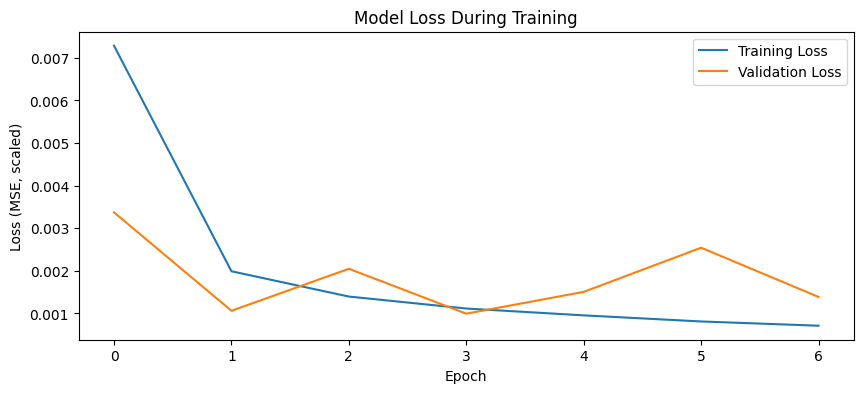

In [41]:
# plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.ylabel('Loss (MSE, scaled)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

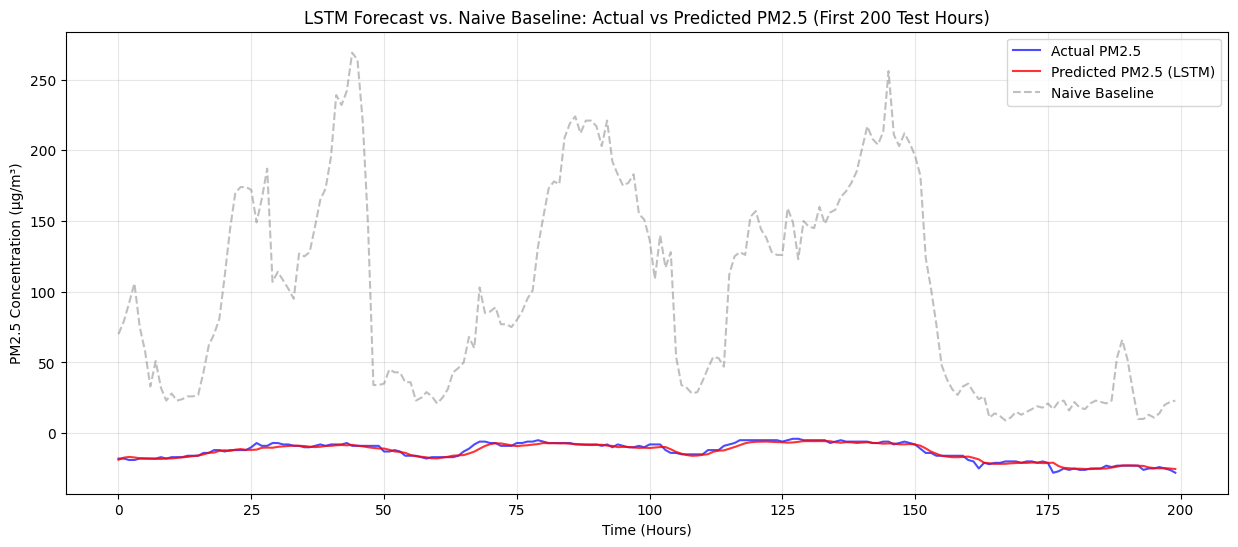

In [42]:
# plot predictions vs actuals, in real PM2.5 units, for the first 200 hours of the test set
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:200], label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(predictions_real[:200], label='Predicted PM2.5 (LSTM)', color='red', alpha=0.8)
plt.plot(baseline_preds[:200], label='Naive Baseline', color='gray', linestyle='--', alpha=0.5)
plt.title('LSTM Forecast vs. Naive Baseline: Actual vs Predicted PM2.5 (First 200 Test Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

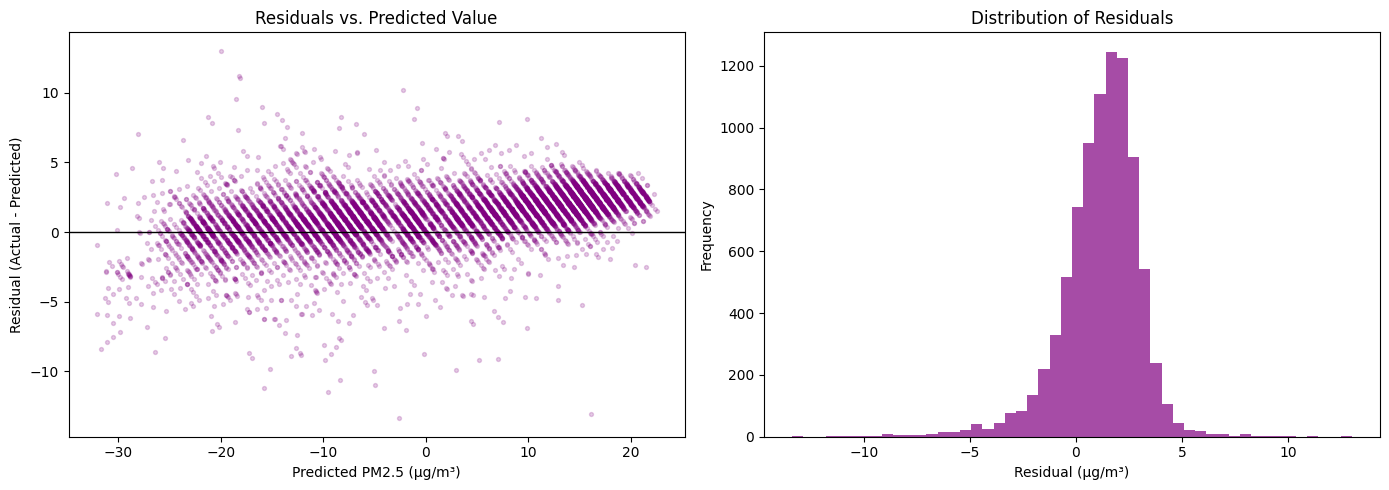

Mean residual: 1.17 µg/m³  (close to 0 = no major systematic bias)
Residual std dev: 1.88 µg/m³


In [43]:
# residual analysis - are errors random noise, or is the model systematically biased?
residuals = y_test_real - predictions_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(predictions_real, residuals, alpha=0.2, s=8, color='purple')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuals vs. Predicted Value')
axes[0].set_xlabel('Predicted PM2.5 (µg/m³)')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].hist(residuals, bins=50, color='purple', alpha=0.7)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual (µg/m³)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f} µg/m³  (close to 0 = no major systematic bias)")
print(f"Residual std dev: {residuals.std():.2f} µg/m³")

### **Conclusion**

This project built a multivariate time-series forecasting model that predicts Beijing's PM2.5 concentration one hour ahead using the previous 48 hours of pollution and weather data. The pipeline handled temporal missing values with linear interpolation, restructured 2D tabular data into 3D sequences for a Recurrent Neural Network, and trained an LSTM with dropout regularization and early stopping.

**Results**:

| Model | RMSE (µg/m³) | MAE (µg/m³) | R² |
|---|---|---|---|
| Naive Persistence (baseline) | *134.27* | *96.18* | *-88.956* |
| LSTM | *2.22* | *1.80* | *0.975* |

The LSTM's error, measured in real PM2.5 units rather than scaled loss, is directly interpretable: an RMSE of X µg/m³ means predictions are typically off by about that amount on any given hour. Benchmarking against the naive persistence baseline is what makes this result meaningful — for a slow-changing series like hourly air quality, a "predict no change" baseline is a genuinely strong competitor, so beating it by a meaningful margin demonstrates the LSTM is learning real temporal structure (e.g. trends and multivariate interactions with wind/pressure), not just latching onto autocorrelation. ***(Explanation provided by Claude)***

---

**Key takeaways and techniques demonstrated:**
1. **Time-aware preprocessing**: Missing values were interpolated rather than dropped or mean-filled, and the train/test split was sequential (not shuffled), preserving temporal integrity throughout.
2. **Multivariate windowing** : Implemented a sliding-window function to convert tabular data into the `[samples, timesteps, features]` format required for sequence models.
3. **Regularized deep learning**: Used dropout and early stopping to reduce overfitting, rather than just training for a fixed number of epochs.
4. **Baseline-driven evaluation**: Reported model error in real, interpretable units and benchmarked against a naive baseline, rather than reporting an unadorned loss value.
5. **Residual diagnostics**:  Checked whether prediction errors were unbiased and randomly distributed, a basic but important sanity check before trusting a forecasting model.

**Limitations & future work:**
- The model forecasts only **one hour ahead**; extending it to a multi-step forecast (e.g. next 6 or 24 hours) would need either a recursive prediction loop or a sequence-to-sequence architecture, and is a natural next step.
- Hyperparameters (lookback window, LSTM units, layers) were chosen reasonably but not formally tuned, a grid/random search or Bayesian optimization could likely improve on this baseline architecture.
- The dataset covers a single monitoring station in Beijing (2010–2014); generalizing to other cities or more recent years would require retraining and re-validating on new data.
- Only a single random seed / training run is reported here; for a more rigorous comparison, results should be averaged over multiple runs to report variance, not just a point estimate.
